# Hospital Database Analysis — Exploratory Data Analysis (EDA)

**Author:** Lokanath Satapathy
**Dataset:** [Hospital Management Dataset (Kaggle)](https://www.kaggle.com/datasets/kanakbaghel/hospital-management-dataset)
**Tables:** patients, doctors, appointments, treatment, billing

This notebook explores the hospital operations dataset with visualizations covering patient demographics, doctor performance, appointment outcomes, revenue trends, and billing risk — a companion to the SQL analysis (`hospital_analysis.sql`) in this repo.

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.max_columns", None)

## 2. Load Data

Update the paths below if your CSVs live in a different folder.

In [3]:
patients = pd.read_csv("patients.csv")
doctors = pd.read_csv("doctors.csv")
appointments = pd.read_csv("appointments.csv")
treatment = pd.read_csv("treatments.csv")
billing = pd.read_csv("billing.csv")

for name, df in [("patients", patients), ("doctors", doctors), ("appointments", appointments),
                  ("treatment", treatment), ("billing", billing)]:
    print(f"{name}: {df.shape[0]} rows, {df.shape[1]} columns")

patients: 50 rows, 11 columns
doctors: 10 rows, 8 columns
appointments: 200 rows, 7 columns
treatment: 200 rows, 6 columns
billing: 200 rows, 7 columns


## 3. Data Cleaning & Type Conversion

In [5]:
# Parse date columns
patients["date_of_birth"] = pd.to_datetime(patients["date_of_birth"])
patients["registration_date"] = pd.to_datetime(patients["registration_date"])
appointments["appointment_date"] = pd.to_datetime(appointments["appointment_date"])
treatment["treatment_date"] = pd.to_datetime(treatment["treatment_date"])
billing["bill_date"] = pd.to_datetime(billing["bill_date"])

# Derive patient age
patients["age"] = ((pd.Timestamp.today() - patients["date_of_birth"]).dt.days / 365.25).astype(int)

# Quick missing-value check across all tables
for name, df in [("patients", patients), ("doctors", doctors), ("appointments", appointments),
                  ("treatment", treatment), ("billing", billing)]:
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing):
        print(f"{name}")
        print(missing)
print("Missing value check complete.")

Missing value check complete.


## 4. Patient Demographics

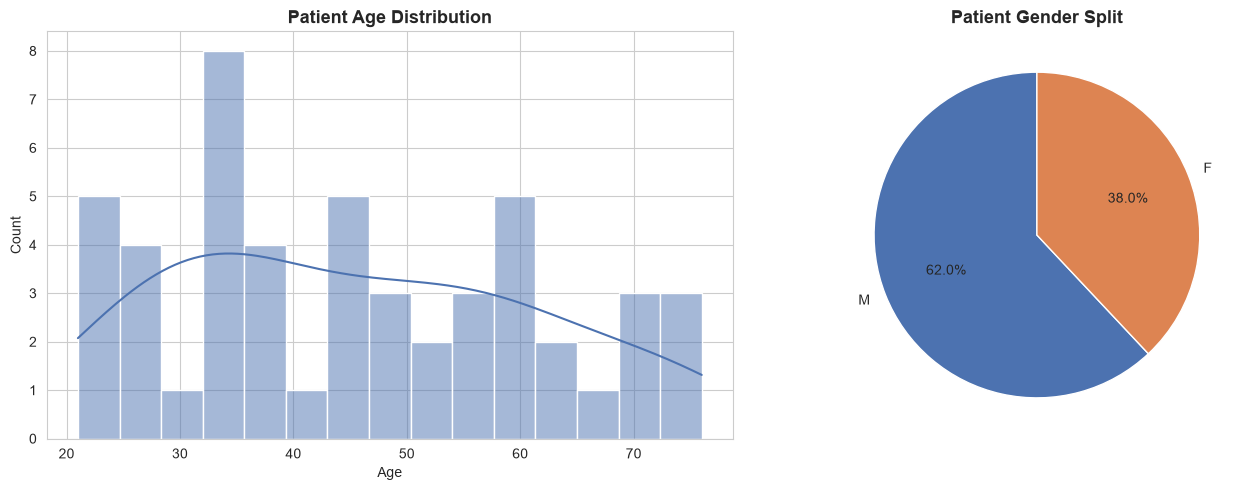

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(patients["age"], bins=15, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Patient Age Distribution")
axes[0].set_xlabel("Age")

gender_counts = patients["gender"].value_counts()
axes[1].pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%",
            colors=["#4C72B0", "#DD8452"], startangle=90)
axes[1].set_title("Patient Gender Split")

plt.tight_layout()
plt.show()

C:\Users\klsat\AppData\Local\Temp\ipykernel_920\1736752464.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_insurance.values, y=top_insurance.index, palette="Blues_r")


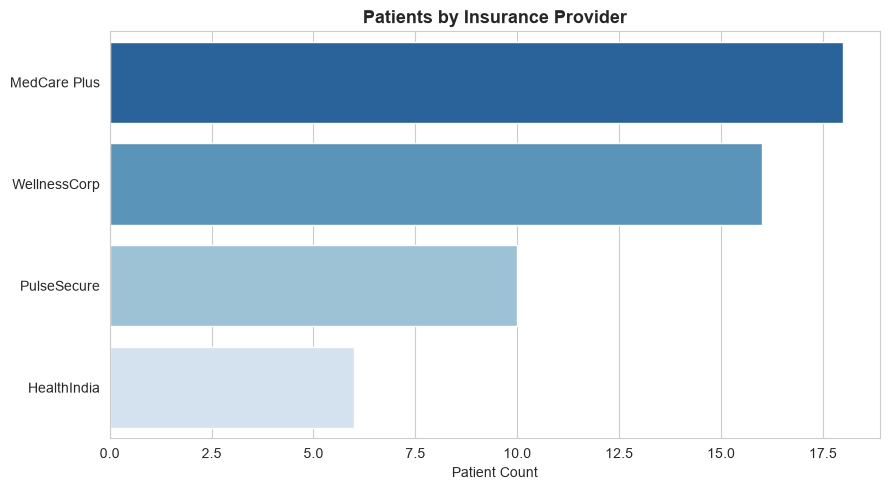

In [7]:
top_insurance = patients["insurance_provider"].value_counts()
plt.figure(figsize=(9, 5))
sns.barplot(x=top_insurance.values, y=top_insurance.index, palette="Blues_r")
plt.title("Patients by Insurance Provider")
plt.xlabel("Patient Count")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 5. Doctor Overview

C:\Users\klsat\AppData\Local\Temp\ipykernel_920\4175138010.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=spec_counts.values, y=spec_counts.index, ax=axes[0], palette="Greens_r")


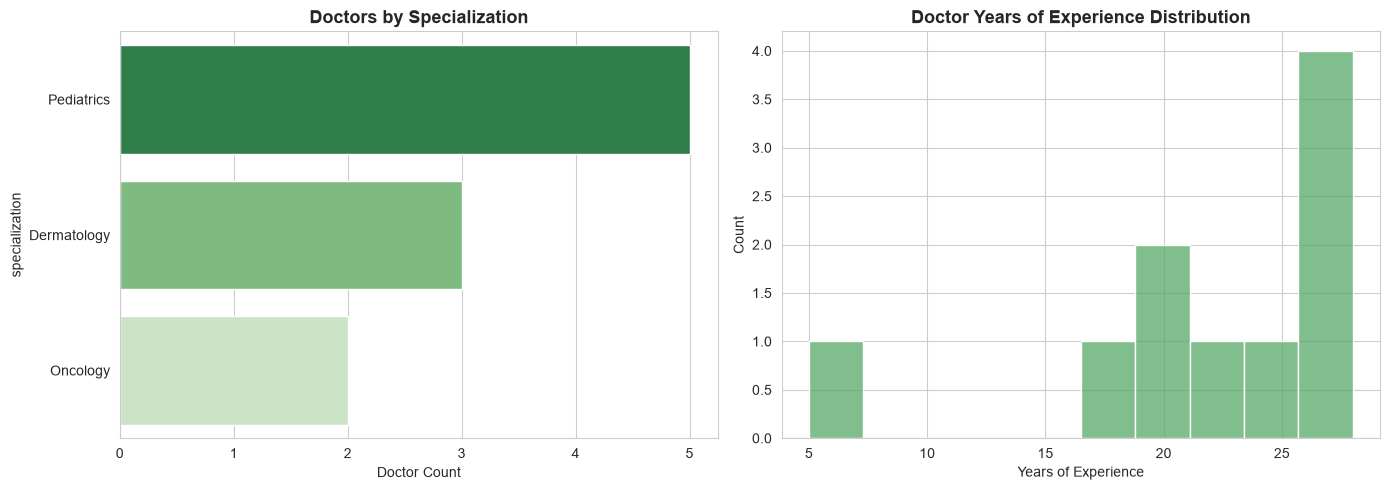

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

spec_counts = doctors["specialization"].value_counts()
sns.barplot(x=spec_counts.values, y=spec_counts.index, ax=axes[0], palette="Greens_r")
axes[0].set_title("Doctors by Specialization")
axes[0].set_xlabel("Doctor Count")

sns.histplot(doctors["years_experience"], bins=10, kde=False, ax=axes[1], color="#55A868")
axes[1].set_title("Doctor Years of Experience Distribution")
axes[1].set_xlabel("Years of Experience")

plt.tight_layout()
plt.show()

## 6. Appointment Outcomes

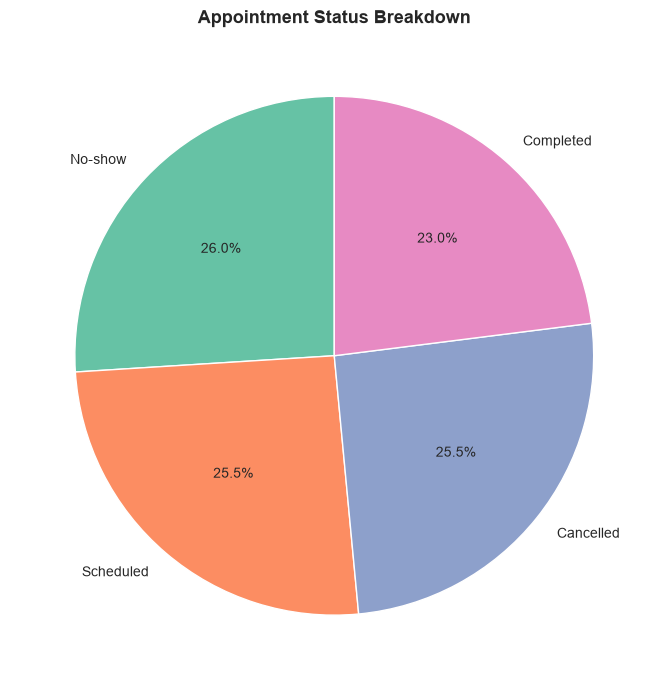

In [9]:
status_counts = appointments["status"].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(status_counts, labels=status_counts.index, autopct="%1.1f%%",
        colors=sns.color_palette("Set2"), startangle=90)
plt.title("Appointment Status Breakdown")
plt.tight_layout()
plt.show()

C:\Users\klsat\AppData\Local\Temp\ipykernel_920\4009438602.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=appointments, x="day_of_week", order=order, palette="viridis")


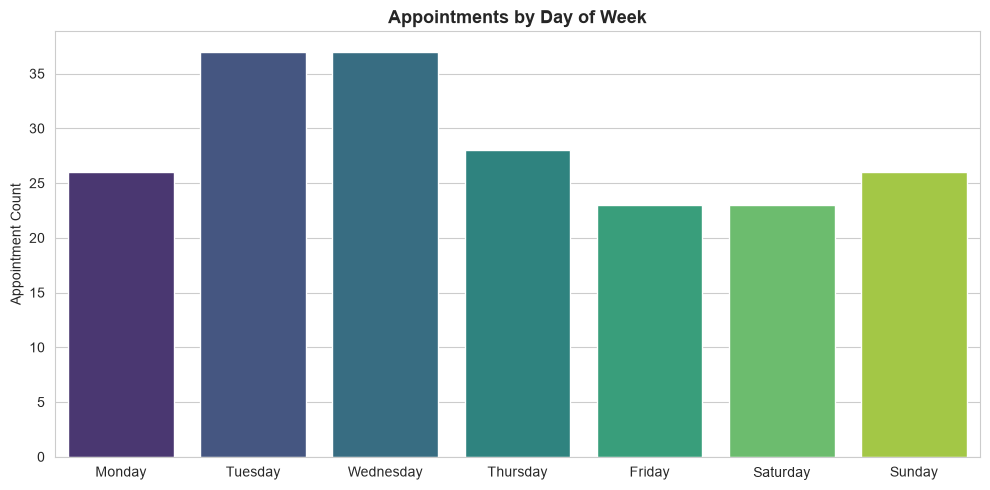

In [10]:
appointments["day_of_week"] = appointments["appointment_date"].dt.day_name()
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

plt.figure(figsize=(10, 5))
sns.countplot(data=appointments, x="day_of_week", order=order, palette="viridis")
plt.title("Appointments by Day of Week")
plt.xlabel("")
plt.ylabel("Appointment Count")
plt.tight_layout()
plt.show()

C:\Users\klsat\AppData\Local\Temp\ipykernel_920\827464704.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=noshow_by_day.index, y=noshow_by_day.values, palette="Reds_r")


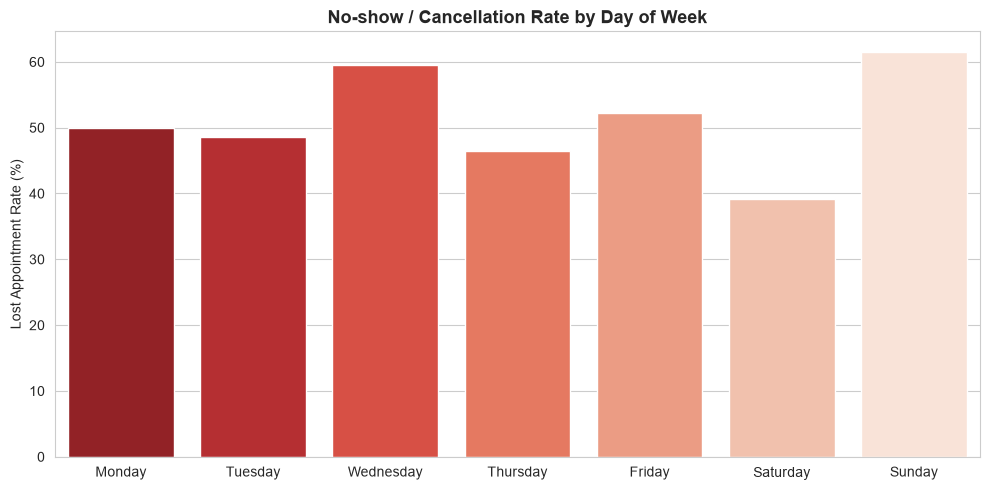

In [11]:
lost_status = ["No-show", "Cancelled"]
noshow_by_day = (
    appointments.assign(is_lost=appointments["status"].isin(lost_status))
    .groupby("day_of_week")["is_lost"]
    .mean()
    .reindex(order) * 100
)

plt.figure(figsize=(10, 5))
sns.barplot(x=noshow_by_day.index, y=noshow_by_day.values, palette="Reds_r")
plt.title("No-show / Cancellation Rate by Day of Week")
plt.ylabel("Lost Appointment Rate (%)")
plt.xlabel("")
plt.tight_layout()
plt.show()

## 7. Treatment & Revenue Analysis

C:\Users\klsat\AppData\Local\Temp\ipykernel_920\3693273813.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=treatment, x="treatment_type", y="cost", palette="coolwarm")


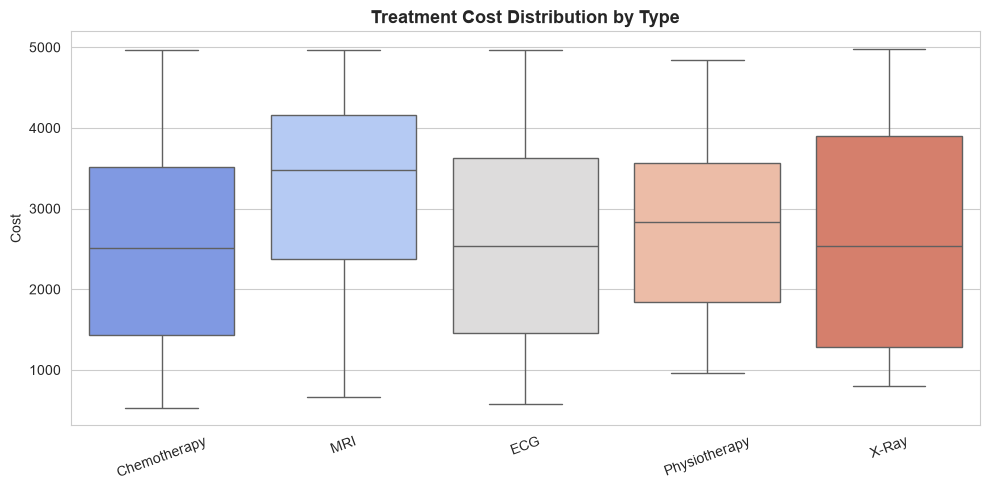

In [12]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=treatment, x="treatment_type", y="cost", palette="coolwarm")
plt.title("Treatment Cost Distribution by Type")
plt.xlabel("")
plt.ylabel("Cost")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

C:\Users\klsat\AppData\Local\Temp\ipykernel_920\2659611772.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=treatment_revenue.values, y=treatment_revenue.index, palette="mako")


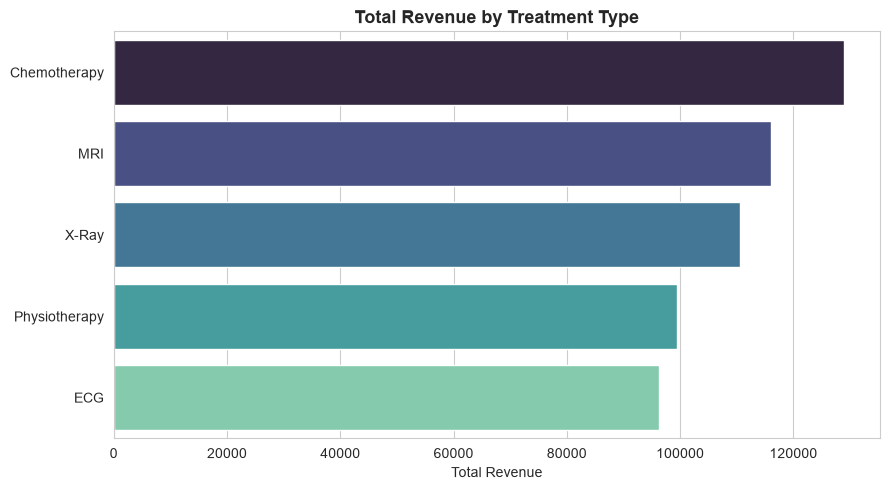

In [13]:
treatment_revenue = treatment.groupby("treatment_type")["cost"].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=treatment_revenue.values, y=treatment_revenue.index, palette="mako")
plt.title("Total Revenue by Treatment Type")
plt.xlabel("Total Revenue")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 8. Monthly Revenue Trend

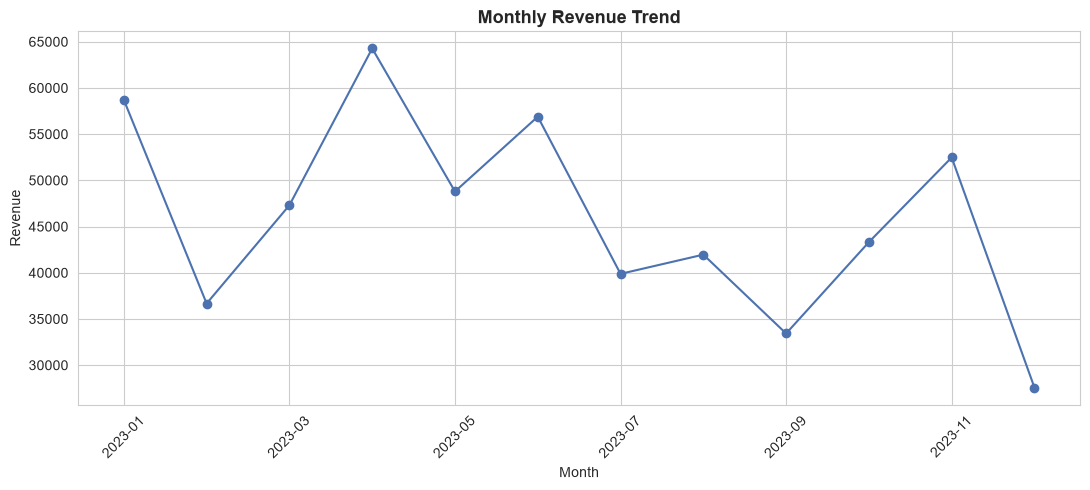

In [14]:
appt_treatment = appointments.merge(treatment, on="appointment_id", how="left")
appt_treatment["appointment_month"] = appt_treatment["appointment_date"].dt.to_period("M").astype(str)

monthly_revenue = appt_treatment.groupby("appointment_month")["cost"].sum()

plt.figure(figsize=(11, 5))
monthly_revenue.plot(marker="o", color="#4C72B0")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 9. Billing & Payment Risk

C:\Users\klsat\AppData\Local\Temp\ipykernel_920\940520554.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=amount_by_status.index, y=amount_by_status.values, ax=axes[1], palette="Oranges_r")


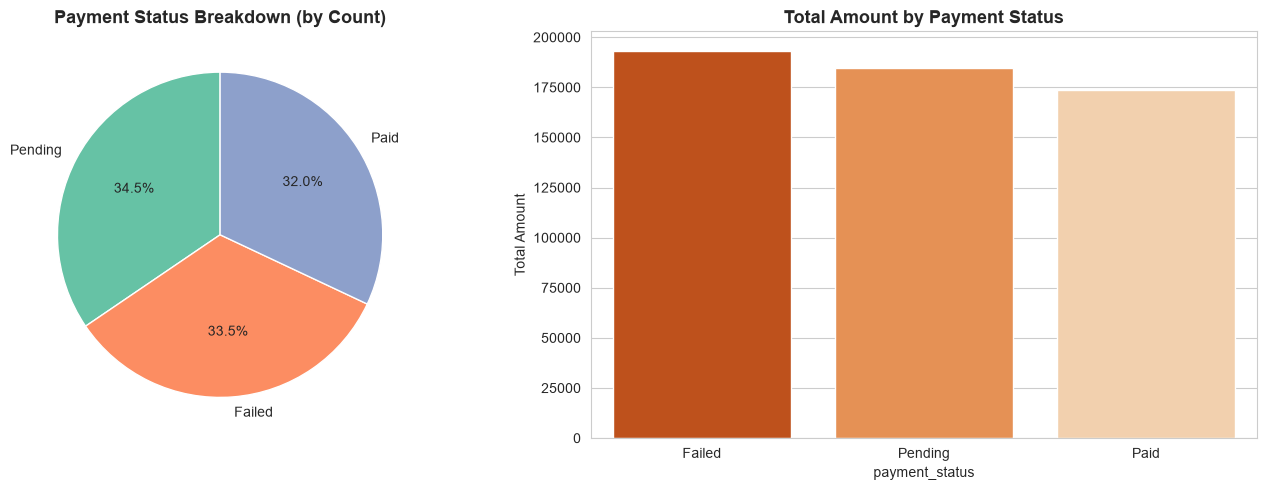

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

payment_status_counts = billing["payment_status"].value_counts()
axes[0].pie(payment_status_counts, labels=payment_status_counts.index, autopct="%1.1f%%",
            colors=sns.color_palette("Set2"), startangle=90)
axes[0].set_title("Payment Status Breakdown (by Count)")

amount_by_status = billing.groupby("payment_status")["amount"].sum().sort_values(ascending=False)
sns.barplot(x=amount_by_status.index, y=amount_by_status.values, ax=axes[1], palette="Oranges_r")
axes[1].set_title("Total Amount by Payment Status")
axes[1].set_ylabel("Total Amount")

plt.tight_layout()
plt.show()

C:\Users\klsat\AppData\Local\Temp\ipykernel_920\3294010808.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=payment_method_counts.values, y=payment_method_counts.index, palette="Purples_r")


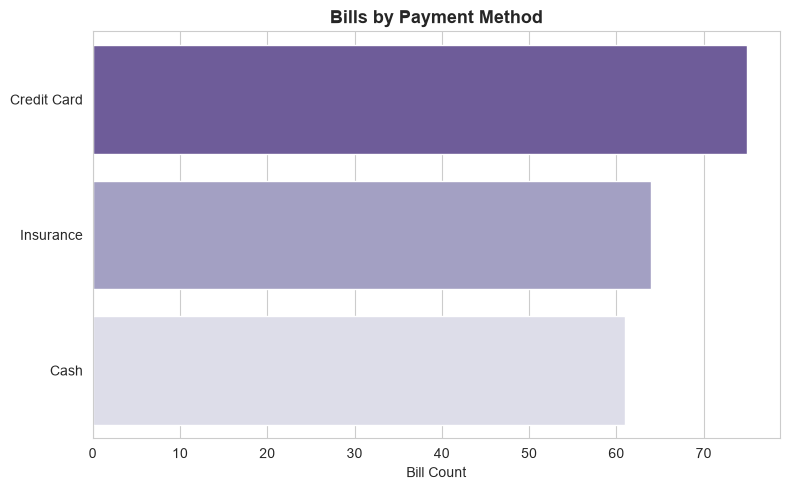

In [16]:
payment_method_counts = billing["payment_method"].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=payment_method_counts.values, y=payment_method_counts.index, palette="Purples_r")
plt.title("Bills by Payment Method")
plt.xlabel("Bill Count")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 10. Summary of Findings

- **Demographics:** age and gender distribution set the baseline patient profile for the hospital.
- **Doctors:** specialization mix and experience spread show where staffing capacity is concentrated.
- **Appointments:** the No-show/Cancelled share quantifies lost scheduling capacity; the day-of-week breakdown flags which days need stronger reminder workflows.
- **Revenue:** treatment-type cost distribution and monthly trend line highlight which services drive revenue and how demand moves over time.
- **Billing:** the payment-status split (by count vs. amount) shows whether financial risk is concentrated in a few high-value bills or spread evenly.

*See `hospital_analysis.sql` in this repo for the full SQL-based analysis with joins, window-function ranking, and RFM patient segmentation.*